In [40]:
import DataMaker
import DataHolder
import buildmodel

import importlib as imp
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
import torch.optim as optim
import torch.optim.lr_scheduler as lr_scheduler
import time

In [41]:
ssplist = ["126","245","370","585"]

In [43]:
# ssplist = ["245"]#,"370","585"]

# set user parameters

latsel = 40
lonsel = 250
historical_era = [1960,2000]
tpercentile = 95
trainvaltest = [np.arange(25),np.arange(25,38),np.arange(38,50)]

inputlength = 10
outputavgtime = 3

# data params
outres = 10
timerange = [1950,2080]
filefront = "MPI_"
inres = 4
inputvar = 'tos'
outputvar = 'tas'

seedlist = [62469869,
            71856281,
            47621498,
            10431957,
            50561320,
            72166634,
            18469465,
            92895735,
            57693846,
            22284750]

In [61]:
imp.reload(DataHolder)

params = {
    "outres": outres,
    "timerange": timerange,
    "filefront": filefront,
    "inres": inres,
    "inputvar":inputvar,
    "outputvar":outputvar,
    "seedlist": seedlist,
}

ntrain = 25
nval = 13
test = np.arange(38,50)

#get the data

AllData = DataHolder.MPIInputOutput_SSPlist(params,ssplist)


data/MPI_annualmean_126_tos.pkl
data/MPI_annualmean_245_tos.pkl
data/MPI_annualmean_370_tos.pkl
data/MPI_annualmean_585_tos.pkl


In [62]:
# plt.subplot(1,1,1)
allpred = []

for iseed, seed in enumerate(seedlist[:1]):

    torch.manual_seed(seed) 
    np.random.seed(seed)

    trainval = np.random.choice(ntrain+nval,ntrain+nval,replace=False)

    trainvaltest = [trainval[:ntrain],trainval[ntrain:ntrain+nval],test]

    alltrain, allval, alltest = AllData.trainvaltest_binaryclassifier(trainvaltest, historical_era,inputlength,outputavgtime, tpercentile, latsel, lonsel)

    inputtrain, inputtrainGMT, outputtrain = DataHolder.tensortime_onehot(alltrain,nclasses=2)
    inputval, inputvalGMT, outputval = DataHolder.tensortime_onehot(allval,nclasses=2)
    inputtest, inputtestGMT, outputtest = DataHolder.tensortime_onehot(alltest,nclasses=2)
    
    outputvalclass = np.argmax(outputval.numpy(),axis=1)

    #baseline of beating gmt, need to get gmt

    # gmtallmembers = AllData.alloutput
    # avgeffectofGMT_train = np.mean(gmtallmembers[:], axis=0)
    # avgeffectofGMTabs = np.round(avgeffectofGMT_train, decimals=0)
    # avgeffectofGMTval = np.tile(avgeffectofGMTabs, (len(trainvaltest[1])))

    # avgeffectofGMT_test = np.mean(gmtallmembers[:], axis=0)

    # yearvec = np.arange(timerange[0]+inputlength, timerange[1]-outputavgtime+2)
    # gmtplot = np.reshape(inputtrainGMT.numpy().squeeze(),(len(trainvaltest[0]),len(yearvec)))
    # gmtplot = np.mean(gmtplot,axis=0)

    cnn = buildmodel.CNNclassifier(inputtrain, inputtrainGMT, outputtrain)
    fileout = "models/"+filefront+"avgtime"+str(outputavgtime)+"_allssps_per"+str(tpercentile)+"_lat"+str(latsel)+"_lon"+str(lonsel)+"_seed"+str(seed)+".pt"
    cnn.load_state_dict(torch.load(fileout, weights_only=True,map_location=torch.device('cpu')) )
    cnn.eval()

    with torch.no_grad():
        predval = cnn(inputval, inputvalGMT)

    predvalclass = torch.argmax(predval, dim=1).numpy()
    allpred.append(predval.numpy())
    acc = np.mean(predvalclass == outputvalclass)
    print("Seed ", str(seed), " val accuracy: ", str(acc))


    predseed = allpred[iseed]
    predseed = np.argmax(predseed, axis=1)
    # predseed = np.reshape(predseed, (len(trainvaltest[1]), len(yearvec)))

    # predseedmean = np.mean(predseed, axis=0)
    # plt.plot(yearvec,predseedmean,label='Seed '+str(seed),linewidth=1.8,color='xkcd:indigo')

    # for i in range(len(trainvaltest[2])):
    #     plt.scatter(yearvec, allpred[iseed][i*len(yearvec):(i+1)*len(yearvec),1], color='xkcd:light purple', s=8)

    #     plt.title('ssp '+ssp + ' tpercentile' + str(tpercentile))

# plt.plot(yearvec,avgeffectofGMT_test,color='xkcd:blue',label='GMT only',linewidth=1.3)
# plt.plot(yearvec,avgeffectofGMTabs,color='xkcd:brown',label='GMT only',linewidth=1.3)

# gmtonlyacc = np.mean(avgeffectofGMTval == outputvalclass)
# print("GMT only val accuracy: ", str(gmtonlyacc))

# plt.xlim(2000,2040)


checking size of inputgmtmean
(50, 1)
checking size of onesigmas
(50,)
working on 126
working on 245
working on 370
working on 585


/Users/egor650/Documents/Experiments/predictability-emergence/DataHolder.py:615: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  


Seed  62469869  val accuracy:  0.7897769982460536


In [70]:
allsummer = []

for i in range(5):
    truesummer = AllData.truesummer[i][25:38].flatten()
    allsummer.extend(truesummer)

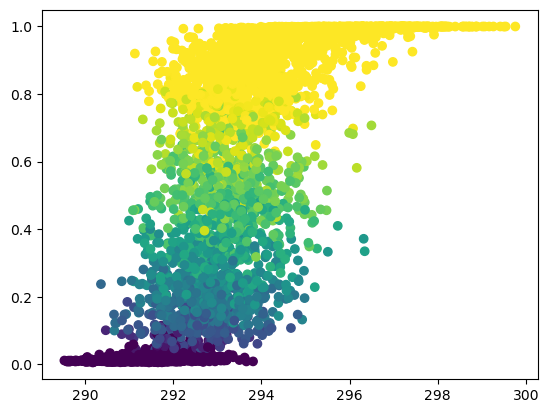

In [73]:
plt.scatter(allsummer,allpred[0][:,1],c=inputvalGMT.numpy(),vmin=0.3,vmax=1)

In [9]:
AllData.input_annualmean.shape

(50, 131, 45, 90)

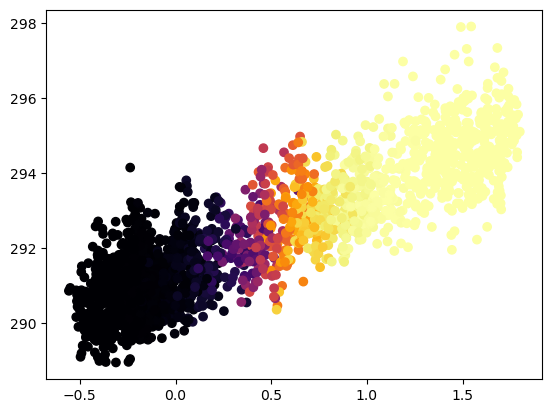

In [ ]:
plt.scatter(inputvalGMT.numpy(),AllData.truesummer[25:38].flatten(),c=allpred[1][:,1],cmap='inferno')

In [ ]:
a = np.arange(7340)

np.percentile(a,100)

7339.0